# Traveler Insights UPTC 2026 — Grupo 5 (BART)
## Parte 1: comprensión de los datos, partición y baseline clásico

Este cuaderno cubre las Fases 1 y 2 de CRISP-ML(Q) y el baseline de la Fase 3.
Cada bloque termina con su **QA: riesgo → método → evidencia**.

Requisitos en Kaggle: adjuntar la competencia como *Input*. Para la celda de longitud en tokens
se necesita *Internet: On* (descarga el tokenizer de BARTO).

In [4]:
import os, re, sys, time, json, random, platform, unicodedata, warnings
import numpy as np, pandas as pd, sklearn, matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker, matplotlib.colors
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline, make_union
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); os.environ["PYTHONHASHSEED"] = str(SEED)

LABELS = ["negativo", "neutral", "positivo"]          # orden fijo en todo el proyecto
LABEL2ID = {l: i for i, l in enumerate(LABELS)}       # negativo=0, neutral=1, positivo=2
CKPT = "vgaraujov/bart-base-spanish"                  # BARTO: checkpoint principal del grupo

# Colores por clase (orden fijo) y tinta de los gráficos
C = {"negativo": "#eb6834", "neutral": "#2a78d6", "positivo": "#1baf7a"}
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e", "xtick.color": MUTED,
                     "ytick.color": MUTED, "axes.titlesize": 11, "axes.titleweight": "bold",
                     "axes.titlelocation": "left", "font.size": 9, "figure.facecolor": "#fcfcfb",
                     "axes.facecolor": "#fcfcfb", "legend.frameon": False})

print("python", platform.python_version(), "| pandas", pd.__version__, "| numpy", np.__version__,
      "| sklearn", sklearn.__version__, "| matplotlib", matplotlib.__version__, "| seed", SEED)

python 3.13.15 | pandas 2.3.3 | numpy 2.1.3 | sklearn 1.6.1 | matplotlib 3.10.0 | seed 42


In [5]:
def find_data_dir():
    # Kaggle: /kaggle/input/<competencia>/ ; local: variable DATA_DIR o carpeta actual
    cands = [os.environ.get("DATA_DIR", ""), "."]
    for root, _, files in os.walk("/kaggle/input"):
        if {"train.csv", "test.csv", "submission.csv"} <= set(files):
            cands.insert(0, root)
    for c in cands:
        if c and os.path.exists(os.path.join(c, "train.csv")):
            return c
    raise FileNotFoundError("No encuentro train.csv: adjunta la competencia como Input")

DATA_DIR = find_data_dir()
OUT_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else os.environ.get("OUT_DIR", ".")
train = pd.read_csv(f"{DATA_DIR}/train.csv")
hold = pd.read_csv(f"{DATA_DIR}/test.csv")          # OJO: viene CON etiqueta
sub = pd.read_csv(f"{DATA_DIR}/submission.csv")     # este es el que se predice (sin etiqueta)
for n, d in [("train", train), ("holdout", hold), ("envio", sub)]:
    d["origen"] = n
todo = pd.concat([train, hold, sub], ignore_index=True)

# QA de esquema: lo que el resto del cuaderno da por cierto
assert todo.ID.is_unique, "hay ID repetidos entre archivos"
assert set(train.Sentimiento) == set(LABELS) and set(hold.Sentimiento) == set(LABELS)
assert sub.Sentimiento.isna().all(), "submission.csv debería venir sin etiqueta"
assert todo.Comentario.notna().all() and (todo.Comentario.str.strip() != "").all()
print({n: len(d) for n, d in [("train", train), ("holdout", hold), ("envio", sub)]}, "| total", len(todo))

{'train': 818, 'holdout': 351, 'envio': 129} | total 1298


## Fase 1 — Comprensión de los datos

**Primera sorpresa:** la descripción dice que `test.csv` no trae etiqueta, pero sí la trae (351 filas).
El archivo que realmente se predice es `submission.csv` (129 filas). El reparto real es 63 % / 27 % / 10 %.
Decisión: `test.csv` se usa como **hold-out local intocable** (no decide hiperparámetros).

Sentimiento  negativo  neutral  positivo  sin etiqueta
origen                                                
envio               0        0         0           129
holdout            10      274        67             0
train              22      639       157             0 

Sentimiento  negativo  neutral  positivo
origen                                  
holdout           2.8     78.1      19.1
train             2.7     78.1      19.2 

Sentimiento  negativo  neutral  positivo
Sitio                                   
Foursquare          0       65       224
Tripadvisor        32      848         0


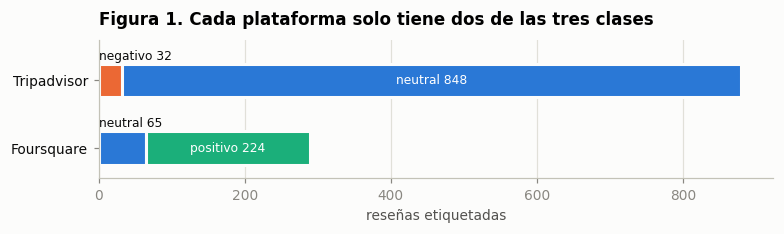

In [6]:
etq = todo[todo.Sentimiento.notna()]
tabla = pd.crosstab(todo.origen, todo.Sentimiento.fillna("sin etiqueta"))
print(tabla, "\n")
print((pd.crosstab(etq.origen, etq.Sentimiento, normalize="index") * 100).round(1), "\n")
print(pd.crosstab(etq.Sitio, etq.Sentimiento))

# Figura 1: clases por plataforma (conteos, train + hold-out)
ct = pd.crosstab(etq.Sitio, etq.Sentimiento).reindex(columns=LABELS, fill_value=0)
fig, ax = plt.subplots(figsize=(7.2, 2.2))
for i, sitio in enumerate(ct.index):
    izq = 0
    for l in LABELS:
        v = ct.loc[sitio, l]
        if v == 0: continue
        ax.barh(i, v, left=izq, color=C[l], height=0.5, edgecolor="#fcfcfb", linewidth=2)
        dentro = v > 120                      # los segmentos pequeños se rotulan encima
        ax.text(izq + v / 2 if dentro else izq, i if dentro else i + 0.36, f"{l} {v}",
                ha="center" if dentro else "left", va="center", fontsize=8,
                color="white" if dentro else INK)
        izq += v
ax.set_yticks(range(len(ct.index))); ax.set_yticklabels(ct.index, color=INK)
ax.set_ylim(-0.45, 1.6)
ax.set_xlabel("reseñas etiquetadas"); ax.xaxis.grid(True, color=GRID); ax.set_axisbelow(True)
ax.set_title("Figura 1. Cada plataforma solo tiene dos de las tres clases", pad=10)
plt.tight_layout(); plt.show()

### Hallazgo central: la etiqueta no es el sentimiento del texto

`Sentimiento` se obtiene aplicando umbrales a `Valoración_num`, que es la **calificación promedio del lugar**
(no de la reseña), y sin normalizar la escala: Foursquare va de 0 a 10 y Tripadvisor de 0 a 5.
La siguiente celda lo verifica.

regla sobre Valoración_num en train: accuracy = 1.0000
regla sobre Valoración_num en holdout: accuracy = 1.0000
lugares (nombre+plataforma): 82 | con más de una etiqueta: 0
los 32 negativos vienen de 2 lugares: {'Ecoparque Laderas de Villeros Coveñas': 4, 'Plaza de Majagual': 28}


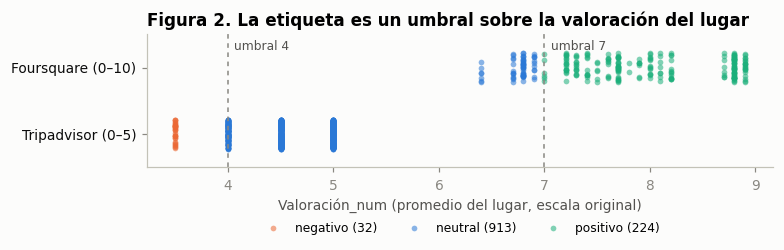

In [7]:
def regla(v):
    return "positivo" if v >= 7 else ("neutral" if v >= 4 else "negativo")

for n, d in [("train", train), ("holdout", hold)]:
    print(f"regla sobre Valoración_num en {n}: accuracy = {(d['Valoración_num'].map(regla) == d.Sentimiento).mean():.4f}")

por_lugar = etq.groupby(["Nombre del lugar", "Sitio"]).Sentimiento.nunique()
print("lugares (nombre+plataforma):", len(por_lugar), "| con más de una etiqueta:", int((por_lugar > 1).sum()))
neg = etq[etq.Sentimiento == "negativo"].groupby("Nombre del lugar").size()
print("los", int(neg.sum()), "negativos vienen de", len(neg), "lugares:", neg.to_dict())

# Figura 2: valoración del lugar vs. etiqueta
fig, ax = plt.subplots(figsize=(7.2, 2.6))
rng = np.random.default_rng(SEED)
for l in LABELS:
    d = etq[etq.Sentimiento == l]
    y = d.Sitio.map({"Foursquare": 1, "Tripadvisor": 0}) + rng.uniform(-0.22, 0.22, len(d))
    ax.scatter(d["Valoración_num"], y, s=14, color=C[l], alpha=0.55, linewidths=0, label=f"{l} ({len(d)})")
for u in (4, 7):
    ax.axvline(u, color=MUTED, lw=1, ls=(0, (3, 3)))
    ax.text(u + 0.06, 1.42, f"umbral {u}", color="#52514e", fontsize=8, va="top")
ax.set_yticks([0, 1]); ax.set_yticklabels(["Tripadvisor (0–5)", "Foursquare (0–10)"], color=INK)
ax.set_ylim(-0.5, 1.5); ax.set_xlabel("Valoración_num (promedio del lugar, escala original)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.32), ncol=3, fontsize=8)
ax.set_title("Figura 2. La etiqueta es un umbral sobre la valoración del lugar")
plt.tight_layout(); plt.show()

**Consecuencias para todo el proyecto**

- Un modelo que lea `Valoración_num` acierta el 100 % sin leer la reseña: eso es un atajo, no análisis de sentimiento.
- Un modelo que solo lee el texto en realidad aprende a reconocer **la plataforma y el lugar** (estilo, longitud,
  nombres propios), no la opinión. Reseñas claramente positivas de Tripadvisor están etiquetadas `neutral`.
- La clase `negativo` son 32 reseñas de 2 lugares: no se puede generalizar a lugares nuevos.
- Esto define el techo del modelo de texto y explica la mayoría de sus "errores" (Fase 4).

             count  mean   std  min   50%   90%    95%    99%    max
Sitio                                                               
Foursquare   321.0   9.0   7.0  1.0   7.0  21.0   25.0   32.0   38.0
Tripadvisor  977.0  52.0  53.0  3.0  35.0  97.0  139.0  294.0  618.0 

             count  mean   std   min   25%   50%   75%    max
Sentimiento                                                  
negativo      32.0  32.6  14.6  16.0  22.8  28.5  37.0   88.0
neutral      913.0  50.0  53.9   2.0  22.0  34.0  58.0  618.0
positivo     224.0   9.2   6.8   1.0   4.0   7.0  12.2   38.0


'[Errno -3] Temporary failure in name resolution' thrown while requesting HEAD https://huggingface.co/vgaraujov/bart-base-spanish/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'[Errno -3] Temporary failure in name resolution' thrown while requesting HEAD https://huggingface.co/vgaraujov/bart-base-spanish/resolve/main/config.json
Retrying in 2s [Retry 2/5].
'[Errno -3] Temporary failure in name resolution' thrown while requesting HEAD https://huggingface.co/vgaraujov/bart-base-spanish/resolve/main/config.json
Retrying in 4s [Retry 3/5].
'[Errno -3] Temporary failure in name resolution' thrown while requesting HEAD https://huggingface.co/vgaraujov/bart-base-spanish/resolve/main/config.json
Retrying in 8s [Retry 4/5].
'[Errno -3] Temporary failure in name resolution' thrown while requesting HEAD https://huggingface.co/vgaraujov/bart-base-spanish/resolve/main/config.json
Retrying in 8s [Retry 5/5].
'[Errno -3] Temporary failure in name resolution' thrown while requesting HEAD https:

config.json:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

[transformers] You are using a model of type `bart` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


tokenizer_config.json:   0%|          | 0.00/277 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/4.78M [00:00<?, ?B/s]


Tokens por reseña:
 count    1298.0
mean       73.0
std        82.0
min         4.0
50%        50.0
90%       144.0
95%       203.0
99%       416.0
max       999.0
Name: n_tok, dtype: float64

  max_length  % truncado total  % truncado Foursquare  % truncado Tripadvisor
         32              75.0                   20.6                    92.8
         64              34.8                    1.2                    45.9
        128              13.1                    0.0                    17.4
        192               6.0                    0.0                     8.0
        256               2.9                    0.0                     3.8
        384               1.2                    0.0                     1.5
        512               0.5                    0.0                     0.6


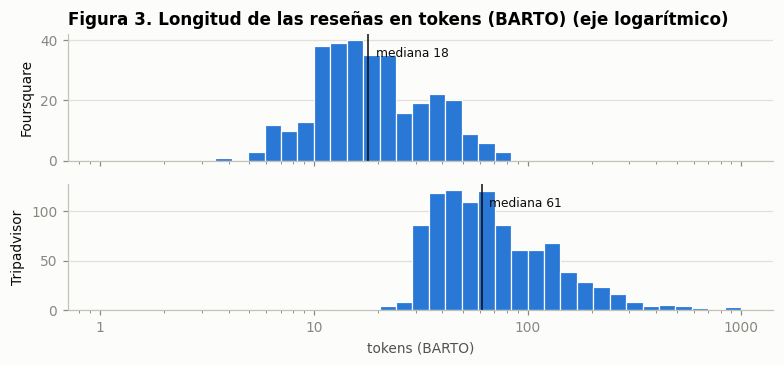

In [8]:
todo["n_car"] = todo.Comentario.str.len()
todo["n_pal"] = todo.Comentario.str.split().str.len()
print(todo.groupby("Sitio").n_pal.describe(percentiles=[.5, .9, .95, .99]).round(0), "\n")
print(todo[todo.Sentimiento.notna()].groupby("Sentimiento").n_pal.describe().round(1))

# Longitud en tokens con el tokenizer del checkpoint (requiere Internet: On en Kaggle)
todo["n_tok"] = np.nan
try:
    from transformers import AutoTokenizer
    tok = AutoTokenizer.from_pretrained(CKPT)
    todo["n_tok"] = [len(x) for x in tok(todo.Comentario.tolist(), add_special_tokens=True)["input_ids"]]
    filas = []
    for m in (32, 64, 128, 192, 256, 384, 512):
        fila = {"max_length": m, "% truncado total": (todo.n_tok > m).mean() * 100}
        for s in ("Foursquare", "Tripadvisor"):
            fila[f"% truncado {s}"] = (todo[todo.Sitio == s].n_tok > m).mean() * 100
        filas.append(fila)
    print("\nTokens por reseña:\n", todo.n_tok.describe(percentiles=[.5, .9, .95, .99]).round(0))
    print("\n", pd.DataFrame(filas).round(1).to_string(index=False))
except Exception as e:
    print("\n[aviso] no se pudo cargar el tokenizer (", type(e).__name__, "): se grafican palabras.")

col = "n_tok" if todo.n_tok.notna().all() else "n_pal"
unidad = "tokens (BARTO)" if col == "n_tok" else "palabras"
fig, axs = plt.subplots(2, 1, figsize=(7.2, 3.4), sharex=True)
bins = np.logspace(0, np.log10(todo[col].max() + 1), 40)
for ax, s in zip(axs, ("Foursquare", "Tripadvisor")):
    d = todo[todo.Sitio == s][col]
    ax.hist(d, bins=bins, color="#2a78d6", edgecolor="#fcfcfb", linewidth=0.8)
    ax.axvline(d.median(), color=INK, lw=1)
    ax.text(d.median() * 1.08, ax.get_ylim()[1] * 0.82, f"mediana {d.median():.0f}", fontsize=8, color=INK)
    ax.set_ylabel(s, color=INK); ax.yaxis.grid(True, color=GRID); ax.set_axisbelow(True)
axs[0].set_title(f"Figura 3. Longitud de las reseñas en {unidad} (eje logarítmico)")
axs[1].set_xscale("log"); axs[1].set_xlabel(unidad)
axs[1].xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda v, _: f"{v:g}"))
plt.tight_layout(); plt.show()

In [9]:
def normalizar(t):
    # Solo para COMPARAR textos (duplicados). No es el preprocesamiento del modelo.
    t = unicodedata.normalize("NFKC", str(t)).lower()
    return re.sub(r"\s+", " ", t).strip()

todo["clave"] = todo.Comentario.map(normalizar)
dup = todo[todo.duplicated("clave", keep=False)]
g = dup.groupby("clave").agg(n=("ID", "size"), origenes=("origen", lambda s: "+".join(sorted(set(s)))),
                             etiquetas=("Sentimiento", lambda s: sorted(set(s.dropna()))))
print("Duplicados exactos:", len(dup), "filas en", len(g), "grupos")
print(g.origenes.value_counts().to_string())
print("grupos con etiquetas contradictorias:", int((g.etiquetas.str.len() > 1).sum()))

pegadas = todo.Comentario.str.contains(r"[a-záéíóúñ][A-ZÁÉÍÓÚÑ][a-záéíóúñ]")
larga = todo.Comentario.map(lambda t: max((len(w) for w in re.findall(r"[^\W\d_]+", t)), default=0)) >= 18
print("\nPalabras pegadas por el scraping (minúscula+Mayúscula o palabra de 18+ letras):")
print(pd.crosstab(todo.Sitio, pegadas | larga).rename(columns={False: "no", True: "sí"}))
print("ejemplos:", todo[(pegadas | larga) & (todo.Sitio == "Foursquare")].Comentario.head(3).tolist())

print("\nReseñas de 1–2 palabras:", int((todo.n_pal <= 2).sum()))
patrones = {"correo": r"[\w.]+@[\w.]+\.\w+", "teléfono": r"(?<!\d)3\d{2}[\s-]?\d{3}[\s-]?\d{4}(?!\d)",
            "url": r"https?://|www\.", "@usuario": r"(?<!\w)@\w+"}
print("Posibles datos personales:", {k: int(todo.Comentario.str.contains(p).sum()) for k, p in patrones.items()})
ingles = todo.Comentario.str.lower().str.contains(r"\b(?:the|and|was|with|this)\b")
print("Reseñas con inglés:", int(ingles.sum()),
      "| con emoji:", int(todo.Comentario.str.contains(r"[\U0001F300-\U0001FAFF\u2600-\u27BF]").sum()))
todo["año"] = todo.Fecha.str.extract(r"((?:19|20)\d{2})")[0].astype(float)
print("\nAño de la reseña por plataforma (mediana):", todo.groupby("Sitio")["año"].median().to_dict())

lug = {n: set(d["Nombre del lugar"] + "|" + d.Sitio) for n, d in [("train", train), ("holdout", hold), ("envio", sub)]}
print(f"Filas del hold-out cuyo lugar ya está en train: {(hold['Nombre del lugar'] + '|' + hold.Sitio).isin(lug['train']).mean():.1%}")
print(f"Filas del envío cuyo lugar ya está en train u hold-out: {(sub['Nombre del lugar'] + '|' + sub.Sitio).isin(lug['train'] | lug['holdout']).mean():.1%}")

Duplicados exactos: 33 filas en 16 grupos
origenes
train            8
holdout+train    3
envio+holdout    3
envio+train      2
grupos con etiquetas contradictorias: 0

Palabras pegadas por el scraping (minúscula+Mayúscula o palabra de 18+ letras):
Comentario    no  sí
Sitio               
Foursquare   268  53
Tripadvisor  971   6
ejemplos: ['Lahamburguesa de polloy elpatacónDoki, son deliciosos.', 'Si quieres conocer sobre la cultura del Municipio, visita a Evaristo AcostaHuertas, vive por elparque principal.Leer más', 'Llegar se hace un poco dispendioso, pero vale la pena por sus hermosasplayaslimpias,tranquilasy sobretodo solas!']

Reseñas de 1–2 palabras: 24
Posibles datos personales: {'correo': 0, 'teléfono': 0, 'url': 2, '@usuario': 1}
Reseñas con inglés: 4 | con emoji: 36

Año de la reseña por plataforma (mediana): {'Foursquare': 2014.0, 'Tripadvisor': 2018.0}
Filas del hold-out cuyo lugar ya está en train: 97.7%
Filas del envío cuyo lugar ya está en train u hold-out: 98.4%


**QA Fase 1 (riesgo → método → evidencia)**

| Riesgo | Método | Evidencia (celdas de arriba) |
|---|---|---|
| Desbalance | Conteo por clase y por plataforma | 78 % neutral, 19 % positivo, 2,7 % negativo; Figura 1 |
| Ruido / validez de etiqueta | Reconstruir la etiqueta con una regla sobre `Valoración_num` | La regla acierta 100 % en train y hold-out; Figura 2 |
| Fuga train/test | Duplicados exactos entre archivos y solapamiento de lugares | Grupos duplicados entre archivos; casi todas las filas de evaluación son de lugares ya vistos |
| Atajos no lingüísticos | Palabras pegadas, longitud y año por plataforma | El texto delata la plataforma, y la plataforma acota la clase |
| Privacidad | Expresiones regulares de correo, teléfono, URL y @usuario | Sin correos ni teléfonos; hay nombres de pila de guías y empleados |

## Fase 2 — Ingeniería de datos

- **Limpieza mínima:** normalización Unicode y espacios. No se pasa a minúsculas, no se quitan tildes, signos ni emojis:
  el tokenizer subword los maneja y llevan señal. Las palabras pegadas no se separan (se documenta como artefacto).
- **Fuga:** se eliminan de `train` las reseñas cuyo texto también está en el hold-out, y los duplicados internos
  quedan siempre en el mismo fold (validación cruzada agrupada por texto).
- **Partición:** 5 folds estratificados con semilla fija. Con 22 negativos, una sola partición 80/20 dejaría
  unos 4 negativos en validación: demasiado ruido para decidir algo.

In [10]:
def limpiar(t):
    t = unicodedata.normalize("NFC", str(t))
    return re.sub(r"\s+", " ", t).strip()

for d in (train, hold, sub):
    d["texto"] = d.Comentario.map(limpiar)
    d["clave"] = d.Comentario.map(normalizar)

antes = len(train)
train = train[~train.clave.isin(set(hold.clave))].reset_index(drop=True)
print(f"train: {antes} -> {len(train)} (se quitan {antes - len(train)} reseñas repetidas en el hold-out)")

N_FOLDS = 5
cv = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
train["fold"] = -1
for k, (_, va) in enumerate(cv.split(train.texto, train.Sentimiento, groups=train.clave)):
    train.loc[va, "fold"] = k
FOLDS = [(np.where(train.fold != k)[0], np.where(train.fold == k)[0]) for k in range(N_FOLDS)]

# Aserciones del pipeline
assert (train.fold >= 0).all()
assert train.groupby("clave").fold.nunique().max() == 1, "un texto duplicado quedó en dos folds"
assert not set(train.clave) & set(hold.clave), "hay texto compartido entre train y hold-out"
assert set(train.Sentimiento) <= set(LABELS) and set(hold.Sentimiento) <= set(LABELS)
assert train.groupby("fold").Sentimiento.nunique().min() == 3, "algún fold se quedó sin una clase"
assert len(sub) == 129 and sub.ID.is_unique
print(pd.crosstab(train.fold, train.Sentimiento))
print("duplicados que NO se pueden quitar (texto del envío presente en train/hold-out):",
      int(sub.clave.isin(set(train.clave) | set(hold.clave)).sum()), "de", len(sub))
train[["ID", "fold"]].to_csv(f"{OUT_DIR}/folds.csv", index=False)   # los mismos folds para BARTO

train: 818 -> 815 (se quitan 3 reseñas repetidas en el hold-out)
Sentimiento  negativo  neutral  positivo
fold                                    
0                   7      129        27
1                   5      125        34
2                   4      128        30
3                   4      126        35
4                   2      128        31
duplicados que NO se pueden quitar (texto del envío presente en train/hold-out): 5 de 129


## Fase 3 — Baseline clásico (no neuronal)

TF-IDF (palabras 1–2 + caracteres 2–5) + Regresión Logística, evaluado en los mismos folds y en el hold-out.
Se reportan también dos referencias que acotan el problema: la clase mayoritaria (piso) y la variante
con metadatos del lugar (muestra cuánto del problema es el atajo).

In [11]:
def modelo_clasico(pesos=None):
    vec = make_union(TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
                     TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), min_df=2, sublinear_tf=True))
    return make_pipeline(vec, LogisticRegression(C=10, max_iter=3000, class_weight=pesos, random_state=SEED))

def con_metadatos(d):
    return "Sitio: " + d.Sitio + " | Lugar: " + d["Nombre del lugar"] + " | Valoración: " + d["Valoración"] + " | " + d.texto

def metricas(y, p):
    return {"acc": accuracy_score(y, p), "f1_macro": f1_score(y, p, average="macro", labels=LABELS, zero_division=0)}

variantes = [("B1 TF-IDF+RL, texto", lambda d: d.texto, None),
             ("B2 TF-IDF+RL, texto, pesos de clase", lambda d: d.texto, "balanced"),
             ("B3 TF-IDF+RL, texto+metadatos, pesos", con_metadatos, "balanced")]
filas, pred = [], {}
m = metricas(train.Sentimiento, ["neutral"] * len(train)); h = metricas(hold.Sentimiento, ["neutral"] * len(hold))
filas.append({"modelo": "B0 clase mayoritaria", "acc_cv": m["acc"], "f1_macro_cv": m["f1_macro"],
              "acc_holdout": h["acc"], "f1_macro_holdout": h["f1_macro"], "tiempo_s": 0.0})
for nombre, entrada, pesos in variantes:
    t0 = time.time()
    p_cv = cross_val_predict(modelo_clasico(pesos), entrada(train), train.Sentimiento, cv=FOLDS)
    clf = modelo_clasico(pesos).fit(entrada(train), train.Sentimiento)
    p_ho = clf.predict(entrada(hold)); pred[nombre] = (p_cv, p_ho, clf, entrada)
    m, h = metricas(train.Sentimiento, p_cv), metricas(hold.Sentimiento, p_ho)
    filas.append({"modelo": nombre, "acc_cv": m["acc"], "f1_macro_cv": m["f1_macro"],
                  "acc_holdout": h["acc"], "f1_macro_holdout": h["f1_macro"], "tiempo_s": time.time() - t0})
m = metricas(train.Sentimiento, train["Valoración_num"].map(regla))   # sin entrenamiento: se aplica a todo train
h = metricas(hold.Sentimiento, hold["Valoración_num"].map(regla))
filas.append({"modelo": "R  regla sobre Valoración_num (atajo)", "acc_cv": m["acc"], "f1_macro_cv": m["f1_macro"],
              "acc_holdout": h["acc"], "f1_macro_holdout": h["f1_macro"], "tiempo_s": 0.0})
resultados = pd.DataFrame(filas)
print(resultados.round(4).to_string(index=False))

                               modelo  acc_cv  f1_macro_cv  acc_holdout  f1_macro_holdout  tiempo_s
                 B0 clase mayoritaria  0.7804       0.2922       0.7806            0.2923    0.0000
                  B1 TF-IDF+RL, texto  0.8798       0.5995       0.8632            0.5184   11.6717
  B2 TF-IDF+RL, texto, pesos de clase  0.8945       0.6940       0.9003            0.7207   10.6735
 B3 TF-IDF+RL, texto+metadatos, pesos  0.9939       0.9934       0.9972            0.9969   12.5241
R  regla sobre Valoración_num (atajo)  1.0000       1.0000       1.0000            1.0000    0.0000


              precision    recall  f1-score   support

    negativo      1.000     0.300     0.462        10
     neutral      0.908     0.974     0.940       274
    positivo      0.852     0.687     0.760        67

    accuracy                          0.900       351
   macro avg      0.920     0.654     0.721       351
weighted avg      0.900     0.900     0.892       351

IC 95 % (bootstrap, n=351): accuracy [0.866, 0.932] | F1 macro [0.567, 0.829]


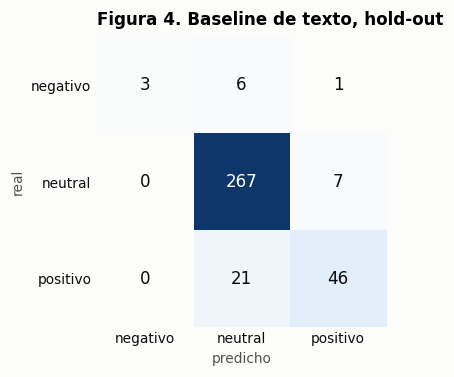

In [12]:
BASE = "B2 TF-IDF+RL, texto, pesos de clase"        # baseline oficial del grupo: solo texto
p_cv, p_ho, clf_base, entrada_base = pred[BASE]
print(classification_report(hold.Sentimiento, p_ho, labels=LABELS, digits=3, zero_division=0))

# Incertidumbre: bootstrap sobre el hold-out
rng = np.random.default_rng(SEED); y = hold.Sentimiento.values; A, F = [], []
for _ in range(2000):
    i = rng.integers(0, len(y), len(y))
    A.append(accuracy_score(y[i], p_ho[i])); F.append(f1_score(y[i], p_ho[i], average="macro", labels=LABELS, zero_division=0))
ic_acc, ic_f1 = np.percentile(A, [2.5, 97.5]), np.percentile(F, [2.5, 97.5])
print(f"IC 95 % (bootstrap, n={len(y)}): accuracy [{ic_acc[0]:.3f}, {ic_acc[1]:.3f}] | F1 macro [{ic_f1[0]:.3f}, {ic_f1[1]:.3f}]")

# Figura 4: matriz de confusión del baseline en el hold-out
cm = confusion_matrix(hold.Sentimiento, p_ho, labels=LABELS)
fig, ax = plt.subplots(figsize=(4.8, 3.5))
ax.imshow(cm, cmap=matplotlib.colors.LinearSegmentedColormap.from_list("azul", ["#fcfcfb", "#cde2fb", "#3987e5", "#0d366b"]))
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=11,
                color="white" if cm[i, j] > cm.max() * 0.5 else INK)
ax.set_xticks(range(3)); ax.set_xticklabels(LABELS, color=INK); ax.set_yticks(range(3)); ax.set_yticklabels(LABELS, color=INK)
ax.set_xlabel("predicho"); ax.set_ylabel("real"); ax.spines[:].set_visible(False); ax.tick_params(length=0)
ax.set_title("Figura 4. Baseline de texto, hold-out", pad=8)
plt.tight_layout(); plt.show()

In [13]:
# ¿Qué está aprendiendo un modelo de solo texto? Tres pruebas de diagnóstico.
p_sitio = cross_val_predict(modelo_clasico("balanced"), train.texto, train.Sitio, cv=FOLDS)
print(f"1) Adivinar la PLATAFORMA desde el texto: accuracy = {accuracy_score(train.Sitio, p_sitio):.3f}")

print("2) Dentro de cada plataforma (entrena y evalúa solo ahí):")
for s in ("Foursquare", "Tripadvisor"):
    a, b = train[train.Sitio == s], hold[hold.Sitio == s]
    q = modelo_clasico("balanced").fit(a.texto, a.Sentimiento).predict(b.texto)
    print(f"   {s:<12} accuracy {accuracy_score(b.Sentimiento, q):.3f} vs. mayoritaria {b.Sentimiento.value_counts(normalize=True).max():.3f} (n={len(b)})")

grupos = train["Nombre del lugar"] + "|" + train.Sitio
cv_lugar = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
q = cross_val_predict(modelo_clasico("balanced"), train.texto, train.Sentimiento, cv=cv_lugar, groups=grupos)
f = f1_score(train.Sentimiento, q, average=None, labels=LABELS, zero_division=0)
print(f"3) Validando con lugares NUNCA vistos: accuracy {accuracy_score(train.Sentimiento, q):.3f} | "
      f"F1 negativo {f[0]:.3f}, neutral {f[1]:.3f}, positivo {f[2]:.3f}")

1) Adivinar la PLATAFORMA desde el texto: accuracy = 0.948
2) Dentro de cada plataforma (entrena y evalúa solo ahí):
   Foursquare   accuracy 0.778 vs. mayoritaria 0.744 (n=90)
   Tripadvisor  accuracy 0.985 vs. mayoritaria 0.962 (n=261)
3) Validando con lugares NUNCA vistos: accuracy 0.838 | F1 negativo 0.000, neutral 0.908, positivo 0.579


**Lectura del baseline**

- El modelo de texto supera con claridad a la clase mayoritaria, pero casi toda la ganancia viene de distinguir
  la plataforma; dentro de cada plataforma apenas mejora a la mayoritaria.
- Con lugares no vistos, el F1 de `negativo` cae a 0: el modelo reconocía el lugar, no la queja.
- Añadir los metadatos del lugar al texto lleva el resultado casi a 100 %. Es una entrada válida en la competencia
  (esas columnas vienen en el archivo de envío), pero convierte la tarea en leer una calificación.
  **Decisión pendiente del grupo, a consultar con el docente:** solo texto (recomendado como modelo principal)
  o texto + metadatos (reportado aparte como experimento).
- `accuracy` premia predecir siempre `neutral` (0,78). Por eso se reporta **F1 macro** junto a la métrica oficial.

In [14]:
# Registro de experimentos (se sigue llenando en la parte de BARTO)
log = resultados.copy()
log.insert(0, "id", ["B0", "B1", "B2", "B3", "R"])
log["cambio"] = ["piso", "baseline", "B1 + pesos de clase", "B2 + metadatos del lugar", "regla (atajo, no es un modelo)"]
log["entrada"] = ["-", "texto", "texto", "texto+metadatos", "Valoración_num"]
log["split"] = f"{N_FOLDS}-fold estratificado agrupado por texto + hold-out"; log["seed"] = SEED
log["fecha"] = time.strftime("%Y-%m-%d %H:%M")
log.round(4).to_csv(f"{OUT_DIR}/experimentos.csv", index=False)
print(log.round(4)[["id", "cambio", "entrada", "acc_cv", "f1_macro_cv", "acc_holdout", "f1_macro_holdout", "tiempo_s"]].to_string(index=False))

id                         cambio         entrada  acc_cv  f1_macro_cv  acc_holdout  f1_macro_holdout  tiempo_s
B0                           piso               -  0.7804       0.2922       0.7806            0.2923    0.0000
B1                       baseline           texto  0.8798       0.5995       0.8632            0.5184   11.6717
B2            B1 + pesos de clase           texto  0.8945       0.6940       0.9003            0.7207   10.6735
B3       B2 + metadatos del lugar texto+metadatos  0.9939       0.9934       0.9972            0.9969   12.5241
 R regla (atajo, no es un modelo)  Valoración_num  1.0000       1.0000       1.0000            1.0000    0.0000


In [15]:
# Archivo de envío del baseline (sirve para comprobar el formato en Kaggle)
FORMATO = "texto"      # "texto": negativo/neutral/positivo como en train | "numero": 0/1/2
p_envio = clf_base.predict(entrada_base(sub))
envio = pd.DataFrame({"ID": sub.ID, "Sentimiento": p_envio})
if FORMATO == "numero":
    envio["Sentimiento"] = envio.Sentimiento.map(LABEL2ID)
assert len(envio) == len(sub) == 129 and envio.ID.is_unique and envio.Sentimiento.notna().all()
envio.to_csv(f"{OUT_DIR}/submission_baseline.csv", index=False)
print(envio.Sentimiento.value_counts().to_dict()); print(envio.head())

{'neutral': 102, 'positivo': 26, 'negativo': 1}
     ID Sentimiento
0   980     neutral
1  1249     neutral
2   260     neutral
3   459     neutral
4   309    positivo


**QA Fases 2–3**

| Riesgo | Método | Evidencia |
|---|---|---|
| Fuga por duplicados | Quitar de train los textos del hold-out; folds agrupados por texto | Aserciones de la celda de partición |
| Folds sin una clase | Estratificación + aserción | Tabla fold × clase |
| Varianza por pocos negativos | 5 folds + bootstrap en hold-out | Intervalo de confianza del baseline |
| Sobreajuste al leaderboard | El hold-out local (351) decide; el leaderboard público se calcula sobre una parte de 129 filas | Cada fila mueve más de 0,7 puntos de accuracy |
| Atajos | Pruebas 1–3 de diagnóstico | Plataforma predecible desde el texto; caída con lugares no vistos |

**Siguiente parte:** fine-tuning de BARTO con los mismos folds (`folds.csv`) y el mismo registro (`experimentos.csv`).